# Phân tích Cân bằng Công việc - Cuộc sống (Work-Life Balance EDA)

**Mục tiêu của Notebook này:**
1. Đánh giá Điểm Cân bằng công việc - cuộc sống (WLB Score) giữa các nhóm Remote, Hybrid và Onsite.
2. Phân tích sự chênh lệch về số giờ làm việc thực tế (Hours_Per_Week) giữa các hình thức làm việc.
3. Tìm ra "điểm bùng phát" (tipping point) nơi số giờ làm việc bắt đầu tỷ lệ thuận với mức độ kiệt sức (Burnout Level).

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from src.data.load_data import load_raw_data
from src.features.build_features import get_da_data,get_ds_data

In [6]:
sns.set_theme(style='whitegrid')
df = load_raw_data()
df_clean = get_da_data(df)

### 1. Hình thức làm việc nào mang lại điểm Work-Life Balance cao nhất?
Giả thuyết đặt ra là nhóm Hybrid sẽ có điểm WLB cao nhất vì họ kết hợp được ưu điểm của cả hai hình thức. Chúng ta sẽ dùng biểu đồ Boxplot để kiểm chứng điều này.

C:\Users\HPC\AppData\Local\Temp\ipykernel_14076\1340774537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Work_Arrangement', y='Work_Life_Balance_Score',


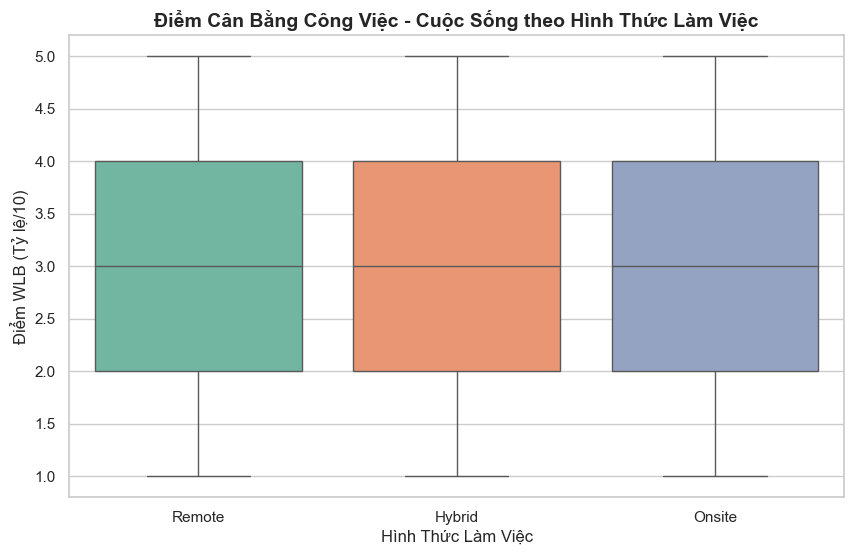

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Work_Arrangement', y='Work_Life_Balance_Score', 
            order=['Remote', 'Hybrid', 'Onsite'], palette='Set2')

plt.title('Điểm Cân Bằng Công Việc - Cuộc Sống theo Hình Thức Làm Việc', fontsize=14, fontweight='bold')
plt.xlabel('Hình Thức Làm Việc', fontsize=12)
plt.ylabel('Điểm WLB (Tỷ lệ/10)', fontsize=12)
plt.show()

**Nhận xét & Insight:**
* **Nhận xét:** Dựa vào biểu đồ Boxplot, nhóm [điền hình thức: ví dụ Hybrid] có mức trung vị (đường gạch ngang giữa hộp) cao nhất ở mức [...]. Nhóm [điền hình thức] có dải phân bố điểm WLB rộng nhất, cho thấy sự chênh lệch lớn giữa các cá nhân trong nhóm này.
* **Insight:** [Điền insight của bạn - Ví dụ: Nhóm Hybrid thực sự tối ưu hóa được chất lượng cuộc sống như lý thuyết nhắc tới, trong khi nhóm Onsite đang chịu áp lực lớn nhất về thời gian cá nhân.]

### 2. Số giờ làm việc thực tế có sự chênh lệch ra sao?
Liệu làm việc ở nhà (Remote) có khiến nhân viên phải làm thêm giờ (Overtime) vô hình nhiều hơn so với việc đến văn phòng (Onsite)?

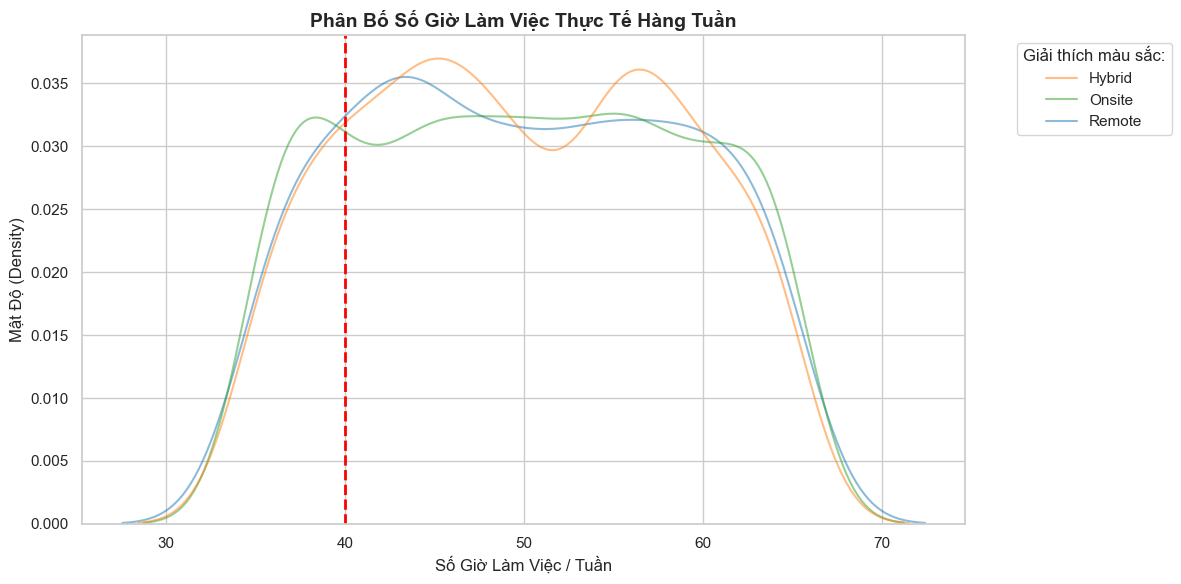

In [20]:
# Cố định màu sắc cho các hình thức làm việc
work_colors = {
    'Remote': '#1f77b4',  # Xanh lam
    'Hybrid': '#ff7f0e',  # Cam
    'Onsite': '#2ca02c'   # Xanh lá
}

plt.figure(figsize=(12, 6))
ax = sns.kdeplot(data=df_clean, x='Hours_Per_Week', hue='Work_Arrangement', 
                 fill=False, common_norm=False, palette=work_colors, alpha=0.5)

plt.title('Phân Bố Số Giờ Làm Việc Thực Tế Hàng Tuần', fontsize=14, fontweight='bold')
plt.xlabel('Số Giờ Làm Việc / Tuần', fontsize=12)
plt.ylabel('Mật Độ (Density)', fontsize=12)
plt.axvline(40, color='red', linestyle='--', linewidth=2, label='Tiêu chuẩn (40h/tuần)')
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1.05, 1), 
                title='Giải thích màu sắc:', frameon=True)
plt.tight_layout() 
plt.show()

**Nhận xét & Insight:**
* **Nhận xét:** Đỉnh chóp của nhóm [điền hình thức] nằm lệch hẳn về phía bên phải của mốc 40 giờ/tuần, tập trung nhiều nhất ở mốc [...] giờ. 
* **Insight:** [Điền insight - Ví dụ: Ranh giới giữa công việc và đời tư của nhóm Remote đang bị xóa nhòa, khiến họ có xu hướng làm việc quá số giờ tiêu chuẩn nhiều hơn hẳn nhóm Onsite.]

### 3. Yếu tố nào "chi phối" mạnh nhất đến Điểm Cân Bằng Công Việc - Cuộc Sống?
Thay vì chỉ đoán mò, chúng ta sẽ dùng Hệ số tương quan Pearson để đo lường mức độ tác động của các biến định lượng (Số giờ làm việc, Mức lương, Mức độ cô lập, Số lượng bệnh lý) lên điểm WLB (Work life balance).
* Hệ số mang giá trị dương (>0): Tỷ lệ thuận (Yếu tố tăng làm WLB tăng).
* Hệ số mang giá trị âm (<0): Tỷ lệ nghịch (Yếu tố tăng làm WLB giảm).

C:\Users\HPC\AppData\Local\Temp\ipykernel_14076\484249289.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wlb_corr['Work_Life_Balance_Score'], y=wlb_corr.index, palette='vlag')


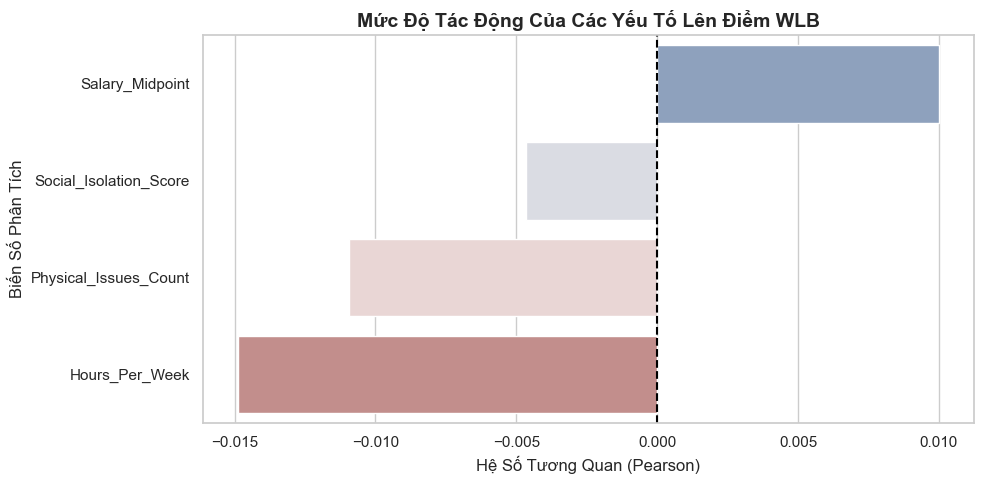

In [22]:
# Chọn các cột số quan trọng cần xét tương quan với WLB
cols_to_corr = [
    'Work_Life_Balance_Score', 
    'Hours_Per_Week', 
    'Salary_Midpoint', 
    'Physical_Issues_Count', 
    'Social_Isolation_Score'
]

# Tính ma trận tương quan
corr_matrix = df_clean[cols_to_corr].corr()

# Rút trích riêng cột WLB, bỏ dòng chính nó (tương quan = 1) và sắp xếp
wlb_corr = corr_matrix[['Work_Life_Balance_Score']].drop('Work_Life_Balance_Score')
wlb_corr = wlb_corr.sort_values(by='Work_Life_Balance_Score', ascending=False)

# Trực quan hóa bằng biểu đồ cột ngang
plt.figure(figsize=(10, 5))
sns.barplot(x=wlb_corr['Work_Life_Balance_Score'], y=wlb_corr.index, palette='vlag')

plt.title('Mức Độ Tác Động Của Các Yếu Tố Lên Điểm WLB', fontsize=14, fontweight='bold')
plt.xlabel('Hệ Số Tương Quan (Pearson)', fontsize=12)
plt.ylabel('Biến Số Phân Tích', fontsize=12)

# Thêm đường mốc 0 ở giữa
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

**Nhận xét & Insight:**
* **Nhận xét:** Nhìn vào biểu đồ tương quan, ta thấy:
    * Yếu tố [điền tên biến có thanh màu xanh/đỏ dài nhất về bên âm, ví dụ: Hours_Per_Week] có hệ số tương quan âm mạnh nhất ([điền chỉ số, ví dụ: -0.45]) đối với điểm WLB.
    * Ngược lại, [điền tên biến] có tương quan dương mạnh nhất, nhưng mức độ tác động nhìn chung [mạnh/yếu].
* **Insight:** Sự đánh đổi là rất rõ ràng. Cột mốc cản trở lớn nhất để nhân sự đạt được sự cân bằng không phải là Thu nhập (Salary) hay sự cô lập, mà chính là [yếu tố âm mạnh nhất]. Điều này bác bỏ quan niệm "lương cao sẽ bù đắp được chất lượng cuộc sống", vì thực tế dữ liệu chứng minh áp lực thời gian/thể chất mới là thứ bào mòn WLB nhanh nhất.